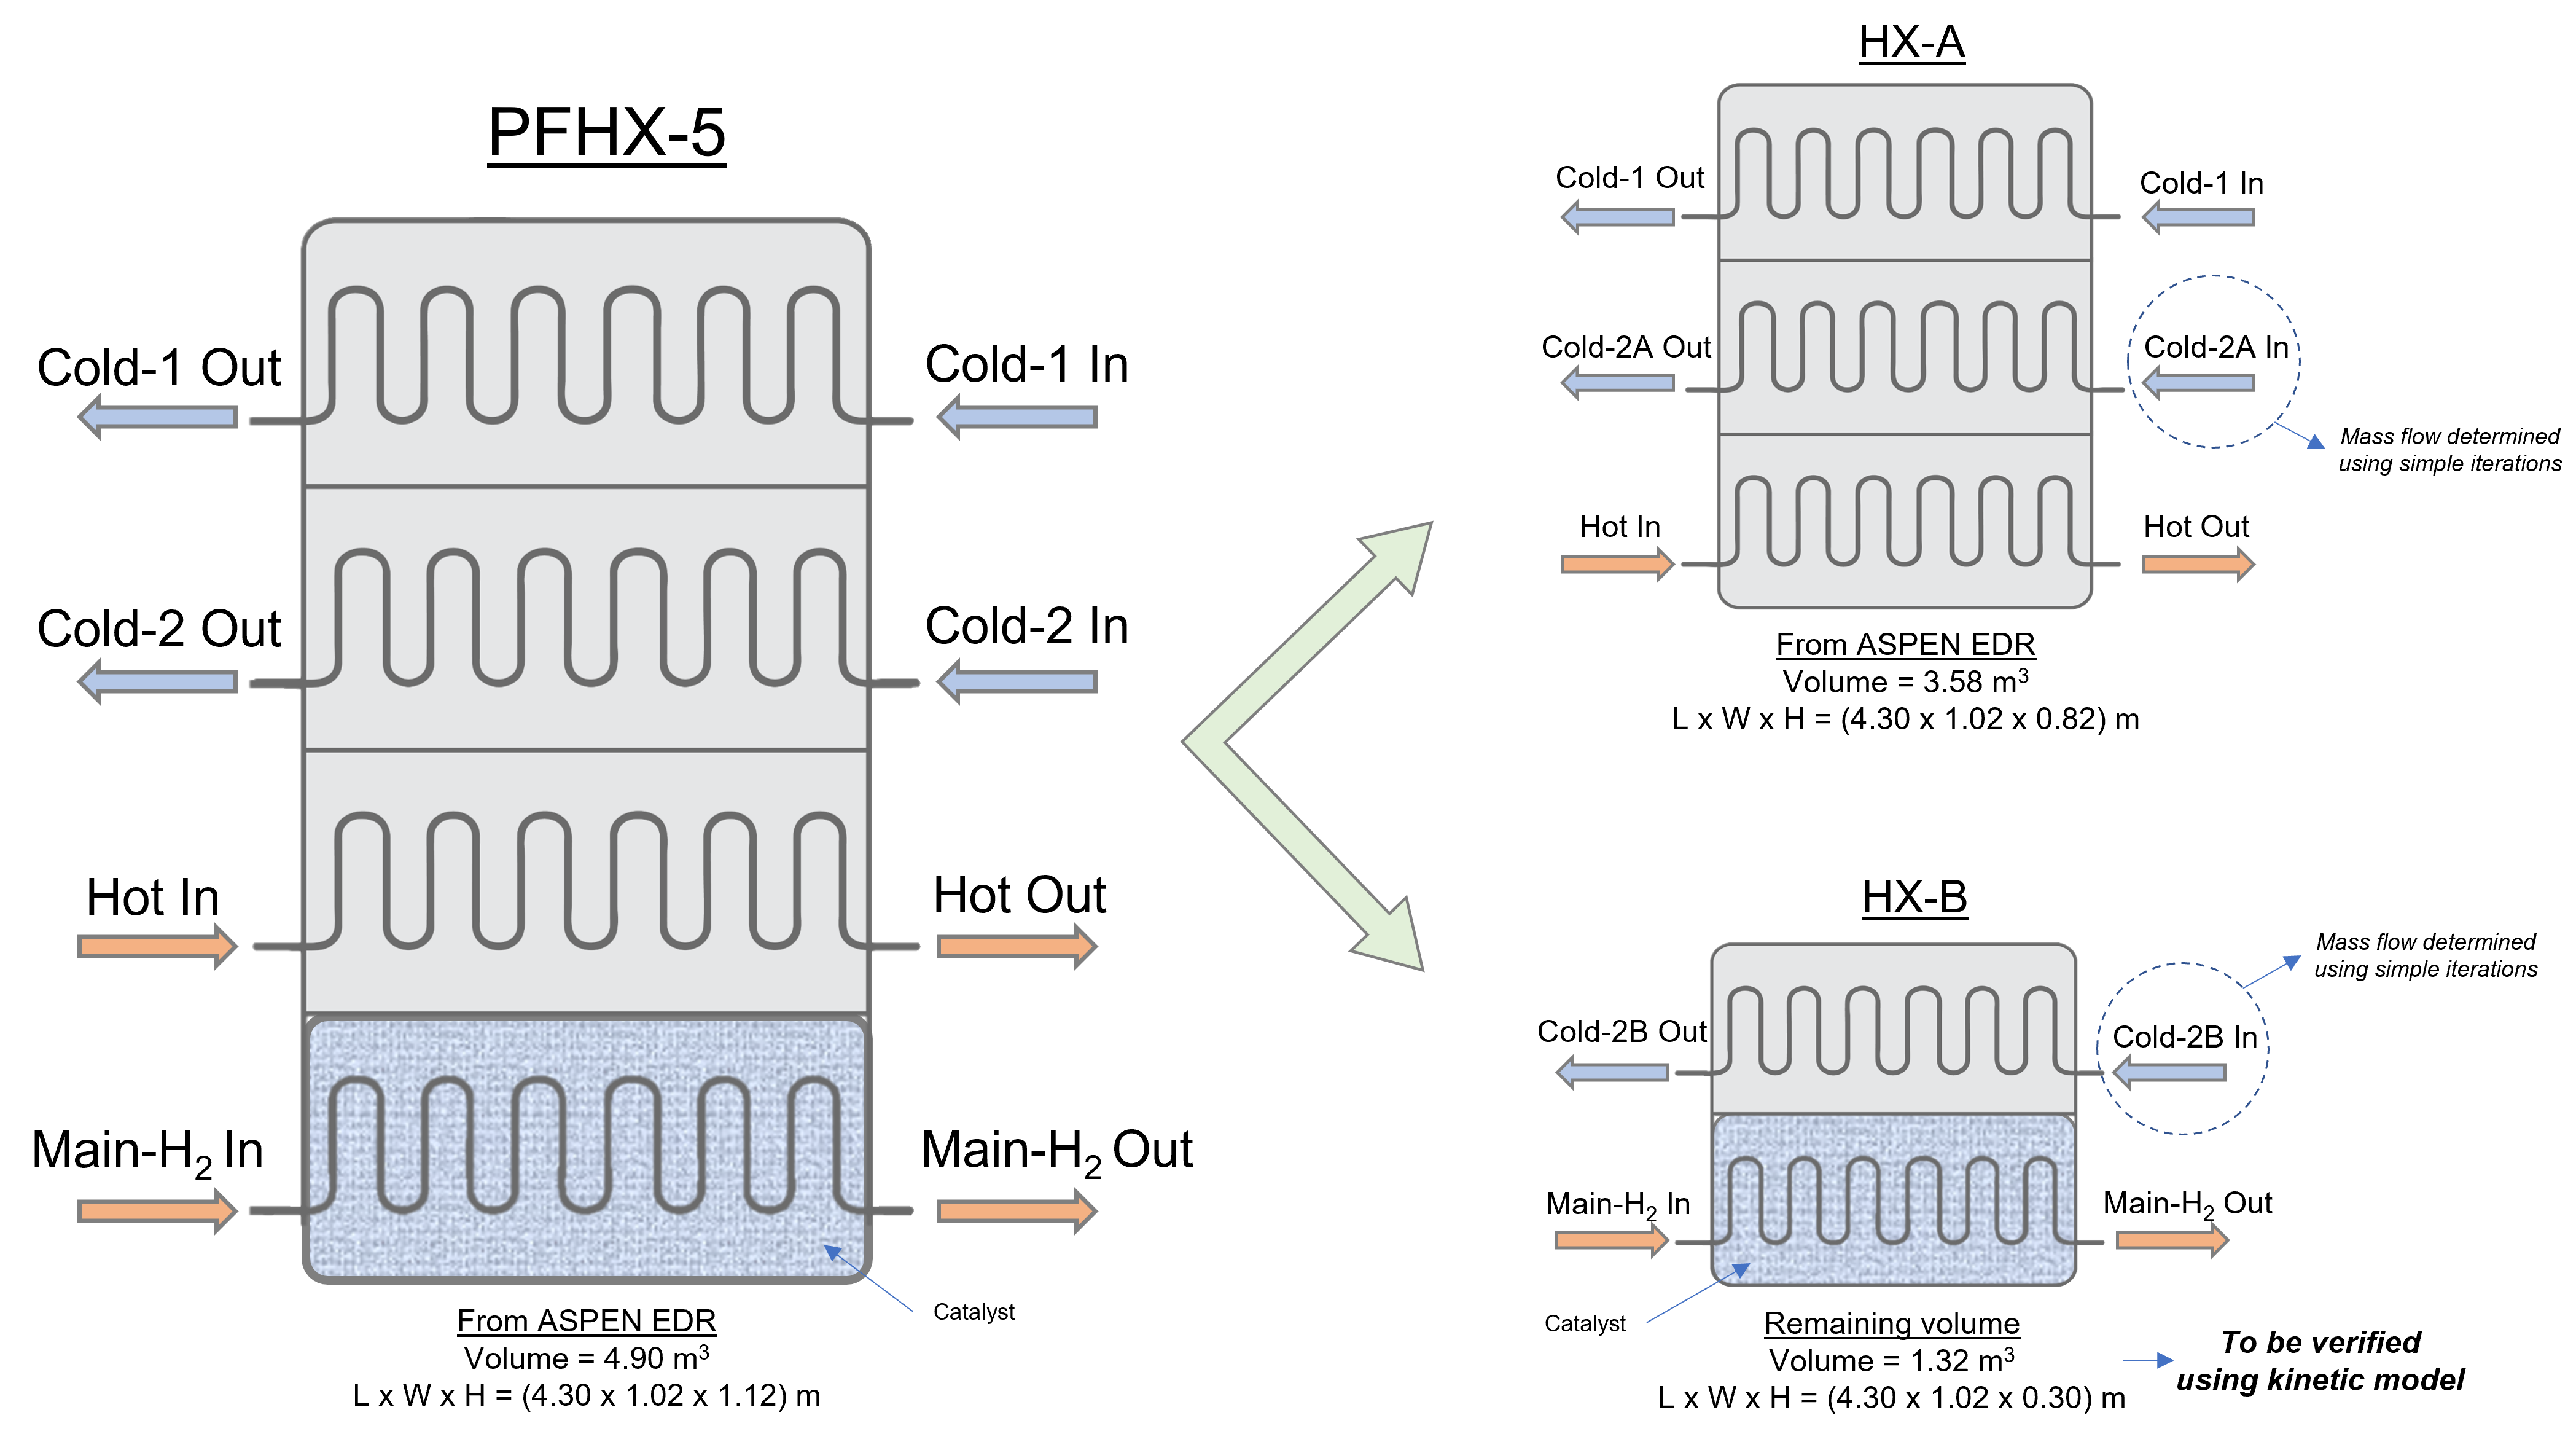

In [1]:
from hydrogen_liquefaction import streamProps

In [2]:
import math
class Format:
    end = '\033[0m'
    underline = '\033[4m'
    
print(Format.underline + "COLD STREAMS" + Format.end + "(from ASPEN HYSYS)")
cold1_In = streamProps.ThermoState("TP", "REFPROP::HYDROGEN", 25.1010088787773, 1.24409000000000*1e5, 2315.232926/3600, "R10")
cold1_In.printState()
cold1_Out = streamProps.ThermoState("TP", "REFPROP::HYDROGEN", 71.9000000000000, 1.19677000000000*1e5, cold1_In.M, "R11")
cold1_Out.printState()

cold2_In = streamProps.ThermoState("TP", "REFPROP::HYDROGEN", 45.1618428113932, 7.79700000000000*1e5, 32188.9835638830/3600, "R21")
cold2_In.printState()
cold2_Out = streamProps.ThermoState("TP", "REFPROP::HYDROGEN", 70.0674656717429, 7.69921000000000*1e5, cold2_In.M, "R21a")
cold2_Out.printState()

print(Format.underline + "HOT STREAMS" + Format.end + "(from ASPEN HYSYS)")
mainH2_In = streamProps.ThermoState("TP", "REFPROP::EQHYDROGEN", 73.500, 19.6181822000000*1e5, 5208/3600, "F05")
mainH2_In.x_para = 0.1/(math.exp(-175/mainH2_In.T)+0.1) - 7.06*(10**-9)*(mainH2_In.T**3) \
                        + 3.42*(10**-6)*(mainH2_In.T**2) - 6.2*(10**-5)*mainH2_In.T - 0.00227
print("F05 p-H2 mole fraction: " + str(round(mainH2_In.x_para,3)))
mainH2_In.printState()
mainH2_Out = streamProps.ThermoState("TP", "REFPROP::EQHYDROGEN", 46.00, 19.55495900*1e5, mainH2_In.M, "F06")
mainH2_Out.printState()

hot_In = streamProps.ThermoState("TP", "REFPROP::HYDROGEN", 74.000, 29.5224300000000*1e5, 18977.31906/3600, "R04a")
hot_In.printState()
hot_Out = streamProps.ThermoState("TP", "REFPROP::HYDROGEN", 47.400, 29.4399500000000*1e5, hot_In.M, "R05")
hot_Out.printState()

##Calculating dummy streams
cold1A_In = streamProps.ThermoState("TP", "REFPROP::HYDROGEN", cold1_In.T, cold1_In.P, cold1_In.M, "R10A")
cold2A_In = streamProps.ThermoState("TP", "REFPROP::HYDROGEN", cold2_In.T, cold2_In.P, cold2_In.M, "R21A")


MH = cold1A_In.M*(cold1A_In.H-cold1_Out.H) + cold2A_In.M*(cold2A_In.H-cold2_Out.H) \
        + hot_In.M*(hot_In.H-hot_Out.H)

while MH < 0:
    """
    if cold1A_In.M > 0:
        cold1A_In.M -= 0.00001
        cold1A_In.M = round(cold1A_In,6)
    """
    cold2A_In.M -= 0.00001
    cold2A_In.M = round(cold2A_In.M,6)
    
    MH = cold1A_In.M*(cold1A_In.H-cold1_Out.H) + cold2A_In.M*(cold2A_In.H-cold2_Out.H) \
            + hot_In.M*(hot_In.H-hot_Out.H)

print(Format.underline + "DUMMY STREAMS" + Format.end)
cold1A_In.printState()
cold2A_In.printState()

cold1B_In = streamProps.ThermoState("TP", "REFPROP::HYDROGEN", cold1_In.T, cold1_In.P, cold1_In.M-cold1A_In.M, "R10B")
cold1B_In.printState()
cold2B_In = streamProps.ThermoState("TP", "REFPROP::HYDROGEN", cold2_In.T, cold2_In.P, cold2_In.M-cold2A_In.M, "R21B")
cold2B_In.printState()

COLD STREAMS(from ASPEN HYSYS)
Stream R10
M [kg/s]    =  0.6431
P [bar]     =  1.244
T [Kelvin]  =  25.1
H [kJ/kg]   =  499.637
S [kJ/kg.K] =  23.5


Stream R11
M [kg/s]    =  0.6431
P [bar]     =  1.197
T [Kelvin]  =  71.9
H [kJ/kg]   =  998.331
S [kJ/kg.K] =  34.931


Stream R21
M [kg/s]    =  8.9414
P [bar]     =  7.797
T [Kelvin]  =  45.16
H [kJ/kg]   =  676.013
S [kJ/kg.K] =  21.701


Stream R21a
M [kg/s]    =  8.9414
P [bar]     =  7.699
T [Kelvin]  =  70.07
H [kJ/kg]   =  959.998
S [kJ/kg.K] =  26.775


HOT STREAMS(from ASPEN HYSYS)
F05 p-H2 mole fraction: 0.528
Stream F05
M [kg/s]    =  1.4467
P [bar]     =  19.618
T [Kelvin]  =  73.5
H [kJ/kg]   =  1294.929
S [kJ/kg.K] =  30.18


Stream F06
M [kg/s]    =  1.4467
P [bar]     =  19.555
T [Kelvin]  =  46.0
H [kJ/kg]   =  730.932
S [kJ/kg.K] =  20.457


Stream R04a
M [kg/s]    =  5.2715
P [bar]     =  29.522
T [Kelvin]  =  74.0
H [kJ/kg]   =  947.817
S [kJ/kg.K] =  21.242


Stream R05
M [kg/s]    =  5.2715
P [bar]     =  29.44
T [

In [3]:
lengthPFHX = 4.06228
widthPFHX = 1.5000
heightPFHX = 1.4229
volumePFHX = lengthPFHX*widthPFHX*heightPFHX

print(Format.underline + "Overall PFHX Geometry" + Format.end)
print("(based on ASPEN EDR)")
print("Length [m]  = ", lengthPFHX)
print("Width  [m]  = ", widthPFHX)
print("Height [m]  = ", heightPFHX)
print("Volume [m3] = ", round(volumePFHX,3))
print("\n")

lengthHXA     = 4.06228
widthHXA      = 1.5000
heightHXA     = 0.9445
volumeHXA     = lengthHXA*widthHXA*heightHXA

print(Format.underline + "HXA Geometry" + Format.end)
print("(based on ASPEN EDR)")
print("Length [m]  = ", lengthHXA)
print("Width  [m]  = ", widthHXA)
print("Height [m]  = ", heightHXA)
print("Volume [m3] = ", round(volumeHXA,3))
print("\n")

volumeHXB     = volumePFHX - volumeHXA
lengthHXB     = lengthPFHX
widthHXB      = widthPFHX
heightHXB     = volumeHXB/(lengthHXB*widthHXB)
print(Format.underline + "HXB Geometry" + Format.end)
print("Length [m]  = ", lengthHXB)
print("Width  [m]  = ", widthHXB)
print("Height [m]  = ", round(heightHXB,3))
print("Volume [m3] = ", round(volumeHXB,3))
print("\n")

Overall PFHX Geometry
(based on ASPEN EDR)
Length [m]  =  4.06228
Width  [m]  =  1.5
Height [m]  =  1.4229
Volume [m3] =  8.67


HXA Geometry
(based on ASPEN EDR)
Length [m]  =  4.06228
Width  [m]  =  1.5
Height [m]  =  0.9445
Volume [m3] =  5.755


HXB Geometry
Length [m]  =  4.06228
Width  [m]  =  1.5
Height [m]  =  0.478
Volume [m3] =  2.915




Adjusted Overall PFHX Geometry
(based on ASPEN EDR)
Length [m]  =  4.06228
Width  [m]  =  1.5
Height [m]  =  1.4229
Volume [m3] =  8.67


HX2 Geometry
Length [m]  =  4.06228
Width  [m]  =  1.5
Height [m]  =  0.478
Volume [m3] =  2.915

###### Running Simulation ######
   Iteration    Max residual  Max BC residual  Total nodes    Nodes added  
       1          3.86e-04       0.00e+00          50              2       
       2          3.87e-04       0.00e+00          52              2       
       3          3.87e-04       0.00e+00          54              1       
       4          8.87e-05       0.00e+00          55              0       
Solved in 4 iterations, number of nodes 55. 
Maximum relative residual: 8.87e-05 
Maximum boundary residual: 0.00e+00


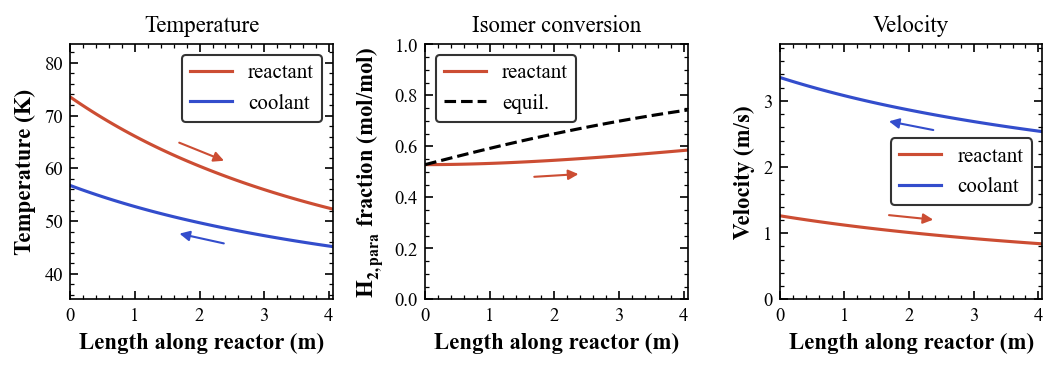

In [4]:
# test for verifying model

### CONFIGURATION ###
configuration = {
    'reactant': {
        'mass_flow_rate': mainH2_In.M*86.4, # tonne-per-day
        'x_para': mainH2_In.x_para,         # para-hydrogen fraction at inlet
        'temperature': mainH2_In.T,         # inlet temperature (K)
        'pressure': mainH2_In.P/1000        # inlet pressure (kPa)
    },
    'coolant': {
        'fluid': "Hydrogen",          # type of coolant
        'x_para': 0.25,               # normal hydrogen
        'mass_flow_rate': cold2B_In.M*86.4,  # tonne-per-day
        'temperature':  cold2B_In.T,        # temperature of coolant at inlet (K)
        'pressure': cold2B_In.P/1000        # pressure of coolant at inlet (kPa)
    },
    'reactor': {
        'length': lengthHXB,                # m
        'width': widthHXB,                 # m
        'height': heightHXB,                # m
        'fin_thickness': 0.2e-3,      # m
        'fin_height': 8.9e-3,         # m
        'fin_pitch': 1.27e-3,         # m
        'seration_length': 3.0e-3,    # m
        'parting_sheet_thickness': 1.5e-3 # m
    },
    'catalyst': {
        'solid_fraction': 0.31,       # volumetric fraction of catlayst particles within reactor
        'diameter': 424.0e-6,         # mean particle diameter
        'density': 4.0                # solid density of catalyst particles (g/cm3)
    },
    'simulation': {
        'nodes': 50,                  # number of nodes across reactor length to setup
        'tolerance': 1.0e-4,          # tolerance of bvp solver
        'delta_t': 1.0                # initial guess of temperature difference between streams
    }
}

# import packages
import matplotlib
from hydrogen_pfhx import model, outputs

print(Format.underline + "Adjusted Overall PFHX Geometry" + Format.end)
print("(based on ASPEN EDR)")
print("Length [m]  = ", lengthPFHX)
print("Width  [m]  = ", widthPFHX)
print("Height [m]  = ", heightPFHX)
print("Volume [m3] = ", round(volumePFHX,3))
print("\n")

print(Format.underline + "HX2 Geometry" + Format.end)
print("Length [m]  = ", lengthHXB)
print("Width  [m]  = ", widthHXB)
print("Height [m]  = ", round(heightHXB,3))
print("Volume [m3] = ", round(volumeHXB,3))

# run the model with config
print('\n###### Running Simulation ######')
results = model.model(configuration)

# plot & display results!
outputs.plot_results(results)
matplotlib.pyplot.draw()

Adjusted Overall PFHX Geometry
(based on ASPEN EDR)
Length [m]  =  7.7
Width  [m]  =  1.5
Height [m]  =  2.9
Volume [m3] =  33.495


HX2 Geometry
Length [m]  =  7.7
Width  [m]  =  1.5
Height [m]  =  1.955
Volume [m3] =  22.586

###### Running Simulation ######
   Iteration    Max residual  Max BC residual  Total nodes    Nodes added  
       1          1.09e-02       0.00e+00          50             58       
       2          2.62e-04       0.00e+00          108             1       
       3          3.38e-04       0.00e+00          109             1       
       4          2.22e-04       0.00e+00          110             1       
       5          2.18e-04       0.00e+00          111             1       
       6          9.09e-05       0.00e+00          112             0       
Solved in 6 iterations, number of nodes 112. 
Maximum relative residual: 9.09e-05 
Maximum boundary residual: 0.00e+00


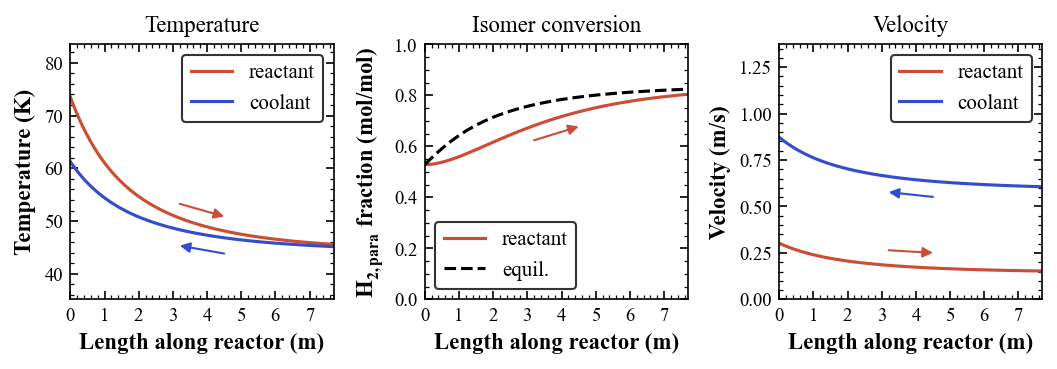

In [5]:
#Adjusted geometry
lengthPFHX = 7.700
widthPFHX  = 1.500
heightPFHX = 2.900
volumePFHX = lengthPFHX*widthPFHX*heightPFHX

lengthHXB     = lengthPFHX
widthHXB      = widthPFHX
heightHXB     = heightPFHX - heightHXA
volumeHXB     = lengthHXB*widthHXB*heightHXB

# test for verifying model

### CONFIGURATION ###
configuration = {
    'reactant': {
        'mass_flow_rate': mainH2_In.M*86.4, # tonne-per-day
        'x_para': mainH2_In.x_para,         # para-hydrogen fraction at inlet
        'temperature': mainH2_In.T,         # inlet temperature (K)
        'pressure': mainH2_In.P/1000        # inlet pressure (kPa)
    },
    'coolant': {
        'fluid': "HYDROGEN",          # type of coolant
        'x_para': 0.25,               # normal hydrogen
        'mass_flow_rate': cold2B_In.M*86.4,  # tonne-per-day
        'temperature':  cold2B_In.T,        # temperature of coolant at inlet (K)
        'pressure': cold2B_In.P/1000        # pressure of coolant at inlet (kPa)
    },
    'reactor': {
        'length': lengthHXB,                # m
        'width': widthHXB,                 # m
        'height': heightHXB,                # m
        'fin_thickness': 0.2e-3,      # m
        'fin_height': 8.9e-3,         # m
        'fin_pitch': 1.27e-3,         # m
        'seration_length': 3.0e-3,    # m
        'parting_sheet_thickness': 1.5e-3 # m
    },
    'catalyst': {
        'solid_fraction': 0.31,       # volumetric fraction of catlayst particles within reactor
        'diameter': 424.0e-6,         # mean particle diameter
        'density': 4.0                # solid density of catalyst particles (g/cm3)
    },
    'simulation': {
        'nodes': 50,                  # number of nodes across reactor length to setup
        'tolerance': 1.0e-4,          # tolerance of bvp solver
        'delta_t': 1.0                # initial guess of temperature difference between streams
    }
}

# import packages
import matplotlib
from hydrogen_pfhx import model, outputs

print(Format.underline + "Adjusted Overall PFHX Geometry" + Format.end)
print("(based on ASPEN EDR)")
print("Length [m]  = ", lengthPFHX)
print("Width  [m]  = ", widthPFHX)
print("Height [m]  = ", heightPFHX)
print("Volume [m3] = ", round(volumePFHX,3))
print("\n")

print(Format.underline + "HX2 Geometry" + Format.end)
print("Length [m]  = ", lengthHXB)
print("Width  [m]  = ", widthHXB)
print("Height [m]  = ", round(heightHXB,3))
print("Volume [m3] = ", round(volumeHXB,3))

# run the model with config
print('\n###### Running Simulation ######')
results = model.model(configuration)

# plot & display results!
outputs.plot_results(results)
matplotlib.pyplot.draw()

In [6]:
print(results)

        Z (m)  Reactant pressure (kPa)  Coolant pressure (kPa)  \
0    0.000000              1961.818220              779.356303   
1    0.078571              1961.714905              779.361017   
2    0.157143              1961.613881              779.365659   
3    0.235714              1961.515025              779.370233   
4    0.314286              1961.418223              779.374742   
..        ...                      ...                     ...   
107  7.385714              1955.704323              779.687550   
108  7.464286              1955.652350              779.690666   
109  7.542857              1955.600456              779.693780   
110  7.621429              1955.548640              779.696891   
111  7.700000              1955.496900              779.700000   

     Reactant temperature (K)  Coolant temperature (K)  \
0                   73.500000                61.248816   
1                   72.163712                60.520186   
2                   70.902381    